In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [101]:
raw_file_url = 'https://raw.githubusercontent.com/atilsamancioglu/MachineLearningNotebooks/refs/heads/main/1-studyhours.csv'

df = pd.read_csv(raw_file_url)


In [102]:
df.head()

,Study Hours,Exam Score
0,3.9,40.0
1,9.6,57.1
2,4.5,42.7
3,11.4,65.1
4,14.4,78.7


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Study Hours  33 non-null     float64
 1   Exam Score   33 non-null     float64
dtypes: float64(2)
memory usage: 660.0 bytes


In [104]:
df.describe()

,Study Hours,Exam Score
count,33.000000,33.000000
mean,15.772727,74.612121
std,7.608723,18.711206
min,3.000000,40.000000
25%,9.600000,58.500000
50%,17.400000,78.800000
75%,21.300000,90.800000
max,30.000000,100.000000


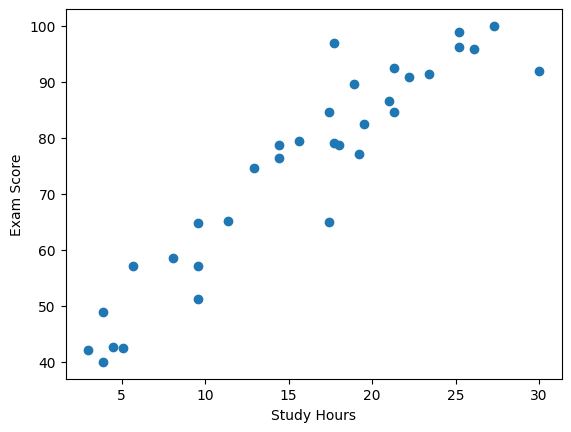

In [105]:
plt.scatter(df['Study Hours'], df['Exam Score'])
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.show()

In [106]:
# INDEPENDENT(X) AND DEPENDENT(y) FEATURES
X = df[['Study Hours']]
y = df['Exam Score']

In [107]:
type(X) # biz x in yani girdiyi dataframe tipinde olmasını isteriz bu nedenle üst satırda iki parantez kullandık

pandas.core.frame.DataFrame

In [108]:
type(y)

pandas.core.series.Series

In [109]:
# TEST - TRAIN SPLIT
''' data setini böleriz, bir kısmını eğitim için
diğer kısmını test için kullanırız'''


' data setini böleriz, bir kısmını eğitim için\ndiğer kısmını test için kullanırız'

In [110]:
from sklearn.model_selection import train_test_split

In [111]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [112]:
y_train

,Exam Score
18,64.9
1,57.1
2,42.7
32,89.6
6,77.1
3,65.1
29,82.4
26,64.8
9,84.6
4,78.7


In [113]:
y_test

,Exam Score
25,42.4
14,86.6
30,91.5
16,57.2
24,51.2
20,49.0
19,84.7


In [114]:
# STANDARDIZE THE DATA SET (STANDARDIZATION)
''' çok büyük yada çok küçük bir şeyi
 standart bir şeye çevirmeye çalışmak

 (veriyi aynı ortalama (0) ve aynı standart
 sapmaya (1) sahip olması için yeniden ölçeklendirilmesidir)
 '''

' çok büyük yada çok küçük bir şeyi\n standart bir şeye çevirmeye çalışmak\n\n (veriyi aynı ortalama (0) ve aynı standart\n sapmaya (1) sahip olması için yeniden ölçeklendirilmesidir)\n '

In [115]:
from sklearn.preprocessing import StandardScaler

In [116]:
df.head()

,Study Hours,Exam Score
0,3.9,40.0
1,9.6,57.1
2,4.5,42.7
3,11.4,65.1
4,14.4,78.7


In [117]:
# balanced feature values
# efficient gradient descent
# l1, l2 (öğrenme sırasında cezalar)

In [120]:
scaler = StandardScaler() # kolonlar arasındaki büyük farklılıkları gidermek için

In [121]:
X_train

,Study Hours
18,17.4
1,9.6
2,4.5
32,18.9
6,19.2
3,11.4
29,19.5
26,9.6
9,17.4
4,14.4


In [122]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # neden buraya fit_ ekelemedik ? çünkü aslında biz train kısmına göre testte hareket edeceğiz bu nedenle fit yapılması gerekmz
# fit -> data leakage

In [124]:
X_test

array([[-1.60435944],
       [ 0.62203261],
       [ 0.95809179],
       [-1.52034465],
       [-0.97424848],
       [-1.77238903],
       [ 0.66404001]])

In [125]:
X_train # standartlaştırıldı -1 ile 1 arasına

array([[ 0.11794385],
       [-0.97424848],
       [-1.68837424],
       [ 0.32798083],
       [ 0.36998823],
       [-0.7222041 ],
       [ 0.41199563],
       [-0.97424848],
       [ 0.11794385],
       [-0.30213013],
       [ 0.15995124],
       [ 0.66404001],
       [-0.13410054],
       [ 1.50418796],
       [-0.51216711],
       [ 0.15995124],
       [-0.30213013],
       [ 1.21013618],
       [ 1.33615837],
       [ 0.7900622 ],
       [-1.77238903],
       [-1.89841122],
       [ 0.20195864],
       [ 1.88225453],
       [-1.18428547],
       [ 1.21013618]])

# **Modeli Eğitmek**

In [126]:
from sklearn.linear_model import LinearRegression

In [127]:
regression = LinearRegression()

In [128]:
regression.fit(X_train, y_train) # eğitildi

LinearRegression()

In [129]:
print("Coefficient: ", regression.coef_)
print("Intercept: ", regression.intercept_)

'''
outputun anlamı: denklem bu;
y = 76.91 + 16.18 X
'''

Coefficient:  [16.17860223]
Intercept:  76.9076923076923


'\noutputun anlamı: denklem bu;\ny = 76.91 + 16.18 X\n'

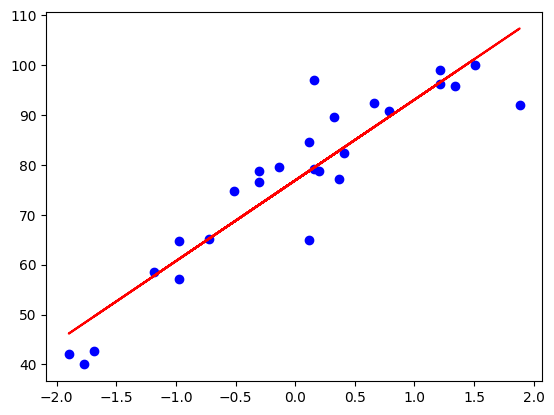

In [130]:
plt.scatter(X_train, y_train, color='blue')
plt.plot(X_train, regression.predict(X_train), color='red') # burada kırmızı ile train bölümündeki datayı tahmin edecek
plt.show()

# çizilen çizgi =  best fit line

In [131]:
# X = 20 , y = ?

In [132]:
regression.predict([[20]]) # 400 verdi ama scale etmem lazım

array([400.47973694])

In [133]:
scaler.transform([[20]]) # scale ettik

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.48200796]])

In [134]:
regression.predict(scaler.transform([[20]])) # 20 saat çalışan biri 84 alırmış

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([84.70590731])

In [136]:
regression.predict(scaler.transform([[10]])) # 10 saat çalışma = 62 not

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([62.05187491])

In [140]:
regression.predict(scaler.transform([[0]])) # 0 saat çalışma = 39 not

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([39.39784252])

# prediction with test data

In [143]:
y_pred_test = regression.predict(X_test)

In [145]:
y_pred_test

array([50.95139904, 86.97131054, 92.40827832, 52.31064098, 61.14571361,
       48.23291515, 87.65093152])

In [147]:
y_test # y_pred_test ile y_test i kıyaslayarak mse, mae vs hatalrı bulmaya çalışacağız

,Exam Score
25,42.4
14,86.6
30,91.5
16,57.2
24,51.2
20,49.0
19,84.7


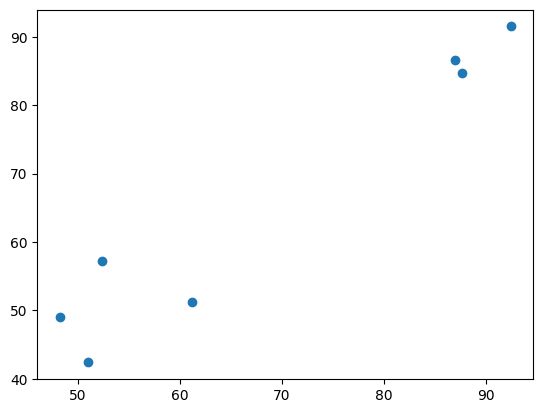

In [148]:
plt.scatter(y_pred_test, y_test)
plt.show()

In [149]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [150]:
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)

print("MSE: ", mse)
print("MAE: ", mae)
print("RMSE: ", rmse)

MSE:  29.45839048833392
MAE:  4.054868128856142
RMSE:  5.427558427906043


In [151]:
r2 = r2_score(y_test, y_pred_test)
print("R2 score: ", r2)

R2 score:  0.9196596206825491


In [154]:
# adjusted R'2 (formülü internette var)
1 - ( 1-r2 ) * ( len(y_test) - 1 ) / ( len(y_test) - X_test.shape[1] - 1 )

0.903591544819059